In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from wordcloud import WordCloud
import seaborn as sns

In [2]:
!python -m spacy download el_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 56.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [4]:
efsyn_full_articles_df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/ΕΡΓΑΣΙΑ DATA JOURNALISM/efsyn_csv/efsyn_teliko.csv')
efsyn_full_articles_df

,Article No,link,title,category,date,author,summary,full_text,Unnamed: 8,Unnamed: 9,...,Unnamed: 596,Unnamed: 597,Unnamed: 598,Unnamed: 599,Unnamed: 600,Unnamed: 601,Unnamed: 602,Unnamed: 603,Unnamed: 604,Unnamed: 605
0,1,https://www.efsyn.gr/politiki/1402509/ntilian-...,Ντίλιαν: Συμπληρώθηκαν οι υπογραφές για κλήση ...,Βουλή,"10/06/2026, 14:31",Ολυμπία Λιάτσου,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...","Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,https://www.efsyn.gr/stiles/1402187/press-poin...,"Press Point: Νικήτα Κακλαμάνη, πάρε τα 2/5 και...",Απόψεις,"10/06/2026, 09:27",ΕΝΤΥΠΗ ΕΚΔΟΣΗΔημήτρης Κανελλόπουλος,NaN,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,https://www.efsyn.gr/kosmos/1401911/tramp-oi-i...,Τραμπ: «Οι Ιρανοί κατέρριψαν το ελικόπτερο Apa...,Βόρεια Αμερική,"09/06/2026, 19:52",efsyn.gr,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,https://www.efsyn.gr/politiki/1401961/epimenei...,Επιμένει ο Φλωρίδης για τις υποκλοπές: «Δεν υπ...,Παρασκήνια,"09/06/2026, 18:46",efsyn.gr,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,https://www.efsyn.gr/politiki/1401876/ypoklope...,Υποκλοπές: Αυξάνεται η πίεση στο Μαξίμου μετά ...,Αντιπολίτευση,"09/06/2026, 17:10",efsyn.gr,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,23,https://www.efsyn.gr/ellada/dikaiosyni/461318_...,Ο Άρειος Πάγος απαλλάσσει το πρόσωπο-κλειδί το...,Δικαιοσύνη,"29/01/2025, 10:34",efsyn.gr,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
456,24,https://www.efsyn.gr/ellada/dikaiosyni/461186_...,Τέσσερις στο εδώλιο για το σκάνδαλο των υποκλοπών,Δικαιοσύνη,"28/01/2025, 12:10",ΕΝΤΥΠΗ ΕΚΔΟΣΗΚώστας Ζαφειρόπουλος,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
457,25,https://www.efsyn.gr/politiki/461132_ypoklopes...,Υποκλοπές: Στο εδώλιο στις 5 Μαρτίου οι Λαβράν...,Πολιτική,"27/01/2025, 18:11",efsyn.gr,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
458,26,https://www.efsyn.gr/politiki/paraskinia/46076...,Ύποπτη καθυστέρηση,Παρασκήνια,"24/01/2025, 07:38",ΕΝΤΥΠΗ ΕΚΔΟΣΗΚ.ΖΑΦ.,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Καθαρισμός δεδομένων

In [6]:
efsyn_full_articles_df.drop_duplicates(inplace=True)
efsyn_full_articles_df.shape

(460, 606)

In [7]:
#Διαγραφή Unnamed στηλών
columns_to_drop = efsyn_full_articles_df.loc[:, 'Unnamed: 8':'Unnamed: 605'].columns.tolist()
efsyn_full_articles_df.drop(columns=columns_to_drop, inplace=True)
efsyn_full_articles_df

,Article No,link,title,category,date,author,summary,full_text
0,1,https://www.efsyn.gr/politiki/1402509/ntilian-...,Ντίλιαν: Συμπληρώθηκαν οι υπογραφές για κλήση ...,Βουλή,2026-06-10 14:31:00,Ολυμπία Λιάτσου,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι...","Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι..."
1,2,https://www.efsyn.gr/stiles/1402187/press-poin...,"Press Point: Νικήτα Κακλαμάνη, πάρε τα 2/5 και...",Απόψεις,2026-06-10 09:27:00,ΕΝΤΥΠΗ ΕΚΔΟΣΗΔημήτρης Κανελλόπουλος,NaN,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...
2,3,https://www.efsyn.gr/kosmos/1401911/tramp-oi-i...,Τραμπ: «Οι Ιρανοί κατέρριψαν το ελικόπτερο Apa...,Βόρεια Αμερική,2026-06-09 19:52:00,efsyn.gr,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...
3,4,https://www.efsyn.gr/politiki/1401961/epimenei...,Επιμένει ο Φλωρίδης για τις υποκλοπές: «Δεν υπ...,Παρασκήνια,2026-06-09 18:46:00,efsyn.gr,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...
4,5,https://www.efsyn.gr/politiki/1401876/ypoklope...,Υποκλοπές: Αυξάνεται η πίεση στο Μαξίμου μετά ...,Αντιπολίτευση,2026-06-09 17:10:00,efsyn.gr,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...
...,...,...,...,...,...,...,...,...
455,23,https://www.efsyn.gr/ellada/dikaiosyni/461318_...,Ο Άρειος Πάγος απαλλάσσει το πρόσωπο-κλειδί το...,Δικαιοσύνη,2025-01-29 10:34:00,efsyn.gr,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...,Στο κενό ακόμη μια έρευνα για τις υποκλοπές • ...
456,24,https://www.efsyn.gr/ellada/dikaiosyni/461186_...,Τέσσερις στο εδώλιο για το σκάνδαλο των υποκλοπών,Δικαιοσύνη,2025-01-28 12:10:00,ΕΝΤΥΠΗ ΕΚΔΟΣΗΚώστας Ζαφειρόπουλος,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...,Για πλημμελήματα θα λογοδοτήσουν στις 5 Μαρτίο...
457,25,https://www.efsyn.gr/politiki/461132_ypoklopes...,Υποκλοπές: Στο εδώλιο στις 5 Μαρτίου οι Λαβράν...,Πολιτική,2025-01-27 18:11:00,efsyn.gr,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...,Οι κατηγορίες που τους αποδίδονται αφορούν πλη...
458,26,https://www.efsyn.gr/politiki/paraskinia/46076...,Ύποπτη καθυστέρηση,Παρασκήνια,2025-01-24 07:38:00,ΕΝΤΥΠΗ ΕΚΔΟΣΗΚ.ΖΑΦ.,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...,Aκόμα περιμένουμε την Εθνική να απαντήσει ποιο...


In [ ]:
efsyn_full_articles_df.dtypes

,0
Article No,object
link,object
title,object
category,object
date,object
author,object
summary,object
full_text,object


In [ ]:
efsyn_full_articles_df.isnull().sum()

,0
Article No,0
link,0
title,0
category,1
date,0
author,9
summary,103
full_text,12


In [ ]:
efsyn_full_articles_df[efsyn_full_articles_df['full_text'].isna()]

,Article No,link,title,category,date,author,summary,full_text
10,11,https://www.efsyn.gr/longform/ypoklopes-oi-10-...,Υποκλοπές: Οι 10 μπλόφες για ένα σκάνδαλο,Θέματα,"07/06/2026, 12:20",ΕΝΤΥΠΗ ΕΚΔΟΣΗΚώστας Ζαφειρόπουλος,"Από το 2022 μέχρι σήμερα, η κυβέρνηση αλλάζει ...",NaN
28,45,https://www.efsyn.gr/politiki/1396430/syriza-g...,ΣΥΡΙΖΑ για πρωτοσέλιδο «Εφ.Συν.»: Η κυβέρνηση ...,Αντιπολίτευση,"02/06/2026, 09:57",NaN,NaN,NaN
36,53,https://www.efsyn.gr/ellada/1393634/areios-pag...,Σκάνδαλο υποκλοπών: Σφοδρές καταγγελίες για νέ...,Δικαιοσύνη,"28/05/2026, 08:33",NaN,NaN,NaN
64,17,https://www.efsyn.gr/politiki/1388138/sfodra-a...,Θύελλα αντιδράσεων για την ακρόαση του διοικητ...,Αντιπολίτευση,"20/05/2026, 16:49",NaN,NaN,NaN
67,20,https://www.efsyn.gr/politiki/1388078/floridis...,Φλωρίδης κατά ΠΑΣΟΚ: Η κλήση Τζαβέλλα ήταν «αν...,Κυβέρνηση,"20/05/2026, 15:20",NaN,NaN,NaN
158,47,https://www.efsyn.gr/politiki/antipoliteysi/51...,Εκτροπή καταγγέλλει ο Ανδρουλάκης και ζητά Εξε...,Αντιπολίτευση,"28/04/2026, 07:32",NaN,NaN,NaN
179,68,https://www.efsyn.gr/ellada/dikaiosyni/509947_...,Ξαναμπαζώνει το σκάνδαλο των υποκλοπών ο Αρειο...,Δικαιοσύνη,"27/04/2026, 09:45",Δανάη Κισκήρα - Μπαρτσώκα,Δεν θα ανασυρθεί από το αρχείο η υπόθεση των τ...,NaN
194,82,https://www.efsyn.gr/politiki/boyli/508297_sfo...,Σφοδρά πυρά Φάμελλου κατά Μητσοτάκη: Είστε ένα...,Βουλή,"16/04/2026, 12:59",efsyn.gr,Να παραιτηθεί άμεσα ο Μητσοτάκης και να προκηρ...,NaN
289,49,https://www.efsyn.gr/politiki/antipoliteysi/50...,ΠΑΣΟΚ: σοβαρές καταγγελίες για γαλάζιο «πάρτι»...,Αντιπολίτευση,"06/03/2026, 11:54",NaN,NaN,NaN
304,64,https://www.efsyn.gr/politiki/synenteyxeis/502...,«Μητσοτάκης ή αλλαγή» με πρωταγωνιστή το ΠΑΣΟΚ,Πολιτική,"28/02/2026, 10:51",NaN,NaN,NaN


#Διαμόρφωση ημερομηνίας

In [8]:
efsyn_full_articles_df['date'] = pd.to_datetime(efsyn_full_articles_df['date'], format='%d/%m/%Y, %H:%M', errors='coerce')

efsyn_full_articles_df
efsyn_full_articles_df.to_csv('efsyn_full_articles_df.csv', index=False)

In [ ]:
efsyn_full_articles_df.dtypes

,0
Article No,object
link,object
title,object
category,object
date,datetime64[ns]
author,object
summary,object
full_text,object


#short_efsyn_df

In [12]:
short_efsyn_df = efsyn_full_articles_df[['date','full_text']].copy()
short_efsyn_df.dropna(subset=['date'], inplace=True)
short_efsyn_df['full_text'].fillna('', inplace=True)
short_efsyn_df.head()

/tmp/ipykernel_1220/4014968651.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  short_efsyn_df['full_text'].fillna('', inplace=True)


,date,full_text
0,2026-06-10 14:31:00,"Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επι..."
1,2026-06-10 09:27:00,Παλεύουν κάποιοι να βρουν άκρη με το θέμα τωνυ...
2,2026-06-09 19:52:00,Προαναγγελία χτυπήματος από τον Αμερικανό πρόε...
3,2026-06-09 18:46:00,Υποστηρίζει εκ νέου ότι η Δικαιοσύνη «ερεύνησε...
4,2026-06-09 17:10:00,Ομαδικά πυρά και εντεινόμενη πίεση προς την κυ...


In [ ]:
short_efsyn_df['year'] = pd.DatetimeIndex(short_efsyn_df['date']).year.astype('Int64')
short_efsyn_df['month'] = pd.DatetimeIndex(short_efsyn_df['date']).month.astype('Int64')
short_efsyn_df['day'] = pd.DatetimeIndex(short_efsyn_df['date']).day.astype('Int64')
short_efsyn_df['hour'] = pd.DatetimeIndex(short_efsyn_df['date']).hour.astype('Int64')

In [ ]:
short_efsyn_df
short_efsyn_df.to_csv('short_efsyn_df.csv', index=False)

In [ ]:
efsyn_full_articles_df.to_csv('efsyn_full_articles_df.csv', index=False)

<Axes: xlabel='month'>

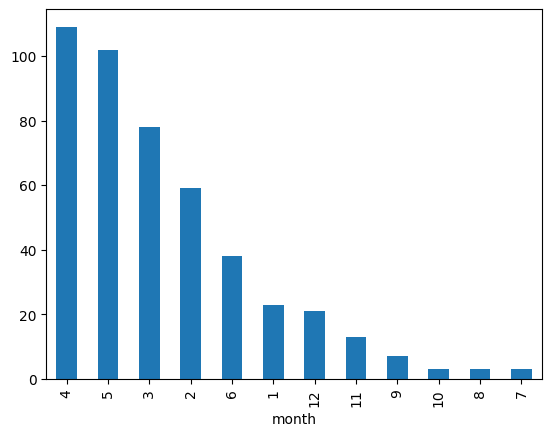

In [ ]:
short_efsyn_df['month'].value_counts().plot(kind='bar')

#Text analysis

In [19]:
text = short_efsyn_df['full_text'].str.cat(sep = ' ')

In [20]:
nlp = spacy.load('el_core_news_sm')

In [ ]:
#Πρώτη προσπάθεια για wordcloud για να πάρουμε μια γενική εικόνα
wordcloud1 = WordCloud(
    stopwords = nlp.Defaults.stop_words,
    width = 2000,
    height = 1000,
    background_color = 'black'
 ).generate(text)
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud1, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
nlp.max_length = len(text) + 1  # Increase the maximum length to accommodate the text
full_doc = nlp(text)

In [ ]:
print(len(text))

1563960


In [ ]:
full_doc[:500]

Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επιτροπή μπορεί να καλεί σε ακρόαση λειτουργούς του κράτους, καθώς και οποιοδήποτε δημόσιο πρόσωπο για θέματα που αφορούν στη λειτουργία των θεσμών και της διαφάνειας, η προσέλευση των οποίων είναι υποχρεωτική». Παρότι συμπληρώθηκε ο απαιτούμενος αριθμός των 2/5 των μελών της που προβλέπει ο κανονισμός, και καθιστά πλέον υποχρεωτική την κλήση του προς ακρόαση, είναι άγνωστο εάν η Επιτροπή Θεσμών και Διαφάνειας της Βουλής θα καλέσει σε ακρόαση τον επιχειρηματίαΤαλ Ντίλιαν, προκειμένου να δώσει απαντήσεις στο σκάνδαλο τωνυποκλοπώνκαι το παράνομο λογισμικό predator, μετά τα αιτήματα που έχει υποβάλει η αντιπολίτευση. Σύμφωνα με όσα ανέφερε στους κοινοβουλευτικούς συντάκτες ο πρόεδρος της Επιτροπής, Θανάσης Μπούρας, μετά τις 20 Ιουνίου θα διεξαχθεί συνεδρίαση για να συζητηθεί το αίτημα της μειοψηφίας, τονίζοντας πωςθα γίνει ό,τι ορίζει ο Κανονισμός της Βουλής. Σύμφωνα με το άρθρο 43Α του Κανονισμού, «η Επιτροπήμπορείνα καλεί σε ακρόαση λειτουργούς

In [ ]:
#Lemmatization
lemmatized_text = ' '.join(token.lemma_ for token in full_doc)

In [ ]:
wordcloud2 = WordCloud(
    stopwords = nlp.Defaults.stop_words,
    width = 2000,
    height = 1000,
    background_color = 'black'
 ).generate(lemmatized_text)
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud2, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig('wordcloud2.png')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Lemmatization without verbs
lemmatized_text_no_verbs = ' '.join(token.lemma_ for token in full_doc if token.pos_ != 'VERB')

wordcloud2 = WordCloud(
    stopwords = nlp.Defaults.stop_words,
    width = 2000,
    height = 1000,
    background_color = 'black'
 ).generate(lemmatized_text_no_verbs)
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'k',
    edgecolor = 'k')
plt.imshow(wordcloud2, interpolation = 'bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.savefig('Efsyn_wordcloud_noverbs.png')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

#Vectorization

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

In [10]:
cv = CountVectorizer()

In [13]:
count_vector = cv.fit_transform(short_efsyn_df['full_text'])

In [16]:
count_vector.shape

(459, 22454)

In [17]:
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()

,00,000,00παρουσίαση,00προέλευση,00προσέλευση,00τέλος,01,010,02,03,...,ύψος,ύψους,ών,ώρα,ώρας,ώρες,ώριμες,ώριμη,ώς,ώστε
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0


Vectorizer με stop words και όρια στις συχνότητες εμφάνισης των λέξεων

In [21]:
cv = CountVectorizer(stop_words= list(nlp.Defaults.stop_words), min_df=0.01, max_df=0.95)

In [22]:
count_vector = cv.fit_transform(short_efsyn_df['full_text'])

In [23]:
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())

results.head()

,00,000,10,100,11,116,12,120,126,13,...,όφειλε,όφελος,όψει,ύπαρξη,ύφος,ύψος,ύψους,ώρα,ώρες,ώς
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,4,0,0,0,1,0,0



Vectorizer με stop words και token pattern



In [24]:
cv = CountVectorizer( stop_words= list(nlp.Defaults.stop_words), token_pattern = '\\bκυβ[α-ωά-ώ]*\\b')
count_vector = cv.fit_transform(short_efsyn_df['full_text'])
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()

,κυβέρνησή,κυβέρνησής,κυβέρνησαν,κυβέρνησε,κυβέρνηση,κυβέρνησηείχε,κυβέρνησηηθικά,κυβέρνησηπροφανώς,κυβέρνησης,κυβέρνησηςαπό,...,κυβερνοεπιχειρήσεις,κυβερνοχώρου,κυβερνούν,κυβερνούσε,κυβερνών,κυβερνώντες,κυβερνώντος,κυβερνώντων,κυβερνώσα,κυβερνώσας
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,11,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0


Vectorizer με ngrams

In [25]:
cv = CountVectorizer( stop_words= list(nlp.Defaults.stop_words), max_features=25, ngram_range=(2, 2))
count_vector = cv.fit_transform(short_efsyn_df['full_text'])
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()

,αξιωματικής αντιπολίτευσης,απόφαση μονομελούς,αρείου πάγου,εθνικής ασφάλειας,εισαγγελέα αρείου,εισαγγελέας αρείου,εξεταστική επιτροπή,εξεταστικής επιτροπής,θεσμών διαφάνειας,κατασκοπευτικό λογισμικό,...,μονομελές πλημμελειοδικείο,μονομελούς πλημμελειοδικείου,νέα δημοκρατία,νέας δημοκρατίας,νίκος ανδρουλάκης,πλημμελειοδικείου αθηνών,πρόεδρος πασοκ,σκάνδαλο υποκλοπών,ταλ ντίλιαν,υπόθεση υποκλοπών
0,0,0,1,0,0,1,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,1,0,0,0,0,0,0,8,2,...,2,1,0,0,0,1,0,1,6,0


In [26]:
results.sum(axis =0).sort_values(ascending = False)

,0
αρείου πάγου,412
σκάνδαλο υποκλοπών,195
κράτος δικαίου,178
ταλ ντίλιαν,148
υπόθεση υποκλοπών,125
μονομελούς πλημμελειοδικείου,122
κράτους δικαίου,99
νέας δημοκρατίας,96
εισαγγελέα αρείου,94
εισαγγελέας αρείου,86


Vectorizer με χρήση λεξικού: sum Λεξεων

In [ ]:
cv = CountVectorizer( stop_words= list(nlp.Defaults.stop_words), max_features=20,
                     vocabulary = ['κατασκοπευτικό', 'κυβέρνηση', 'ντίλιαν', 'συγκάλυψη'])
count_vector = cv.fit_transform(short_efsyn_df['full_text'])
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()

In [29]:
cv = CountVectorizer( stop_words= list(nlp.Defaults.stop_words), max_features=20,
                     vocabulary = ['κατασκοπευτικό', 'κυβέρνηση', 'ντίλιαν', 'συγκάλυψη', 'παράνομες'])
count_vector = cv.fit_transform(short_efsyn_df['full_text'])
results = pd.DataFrame(count_vector.toarray(), columns=cv.get_feature_names_out())
results.head()
print(results.sum(axis=0))

κατασκοπευτικό     61
κυβέρνηση         694
ντίλιαν           303
συγκάλυψη          83
παράνομες          37
dtype: int64


#TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words= list(nlp.Defaults.stop_words), max_features=500)
tfidf_matrix_train = tfidf_vectorizer.fit_transform(short_efsyn_df['full_text'])

In [ ]:
results = pd.DataFrame(tfidf_matrix_train.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
results.head()

,10,11,15,151,2019,2020,2021,2022,2023,2024,...,χαρακτηριστικά,χθες,χρήση,χρήστος,χρόνια,χρόνο,χώρα,χώρας,όνομα,ώρα
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.148299,0.0,0.000000,0.0,0.0,...,0.000000,0.111501,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.000000,0.143897,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.077177,0.0,0.0,...,0.075076,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.069988
4,0.0,0.0,0.0,0.0,0.0,0.113509,0.0,0.000000,0.0,0.0,...,0.000000,0.000000,0.028898,0.0,0.024238,0.0,0.0,0.054167,0.0,0.027084


### Οι 15 πιο συχνές λέξεις στα κείμενα

/tmp/ipykernel_1533/3177629744.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_words.values, y=top_15_words.index, palette='viridis')


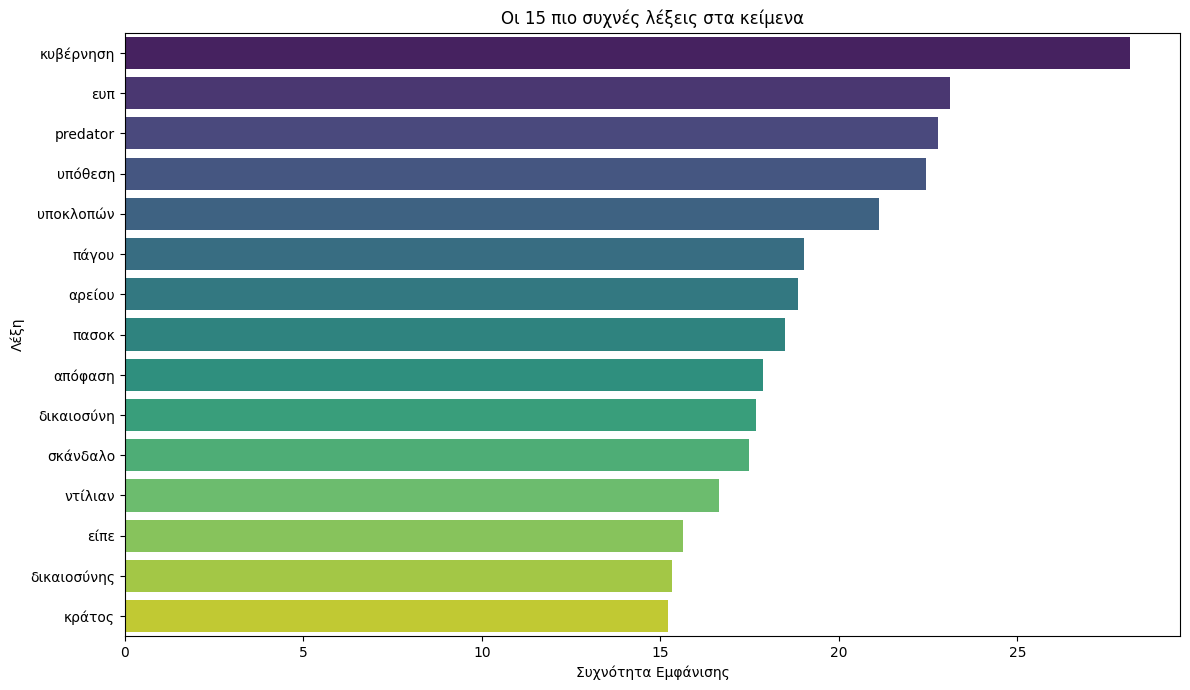

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sum the word counts across all documents to get total frequency for each word
word_frequencies = results.sum(axis=0)

# Get the top 15 most frequent words
top_15_words = word_frequencies.nlargest(15)

# Create a bar chart for the top 15 words
plt.figure(figsize=(12, 7))
sns.barplot(x=top_15_words.values, y=top_15_words.index, palette='viridis')
plt.title('Οι 15 πιο συχνές λέξεις στα κείμενα')
plt.xlabel('Συχνότητα Εμφάνισης')
plt.ylabel('Λέξη')
plt.tight_layout()
plt.show()

### Οι 15 πιο συχνές λέξεις στο λεμματισμένο κείμενο (χωρίς ρήματα)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Reinitialize CountVectorizer for lemmatized text without min_df and max_df restrictions
cv_lemmatized = CountVectorizer(stop_words=list(nlp.Defaults.stop_words))

# Transform the lemmatized text (without verbs)
count_vector_lemmatized = cv_lemmatized.fit_transform([lemmatized_text_no_verbs])

# Create a DataFrame from the transformed data
results_lemmatized = pd.DataFrame(count_vector_lemmatized.toarray(), columns=cv_lemmatized.get_feature_names_out())

/tmp/ipykernel_1533/1528138844.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_words_lemmatized.values, y=top_15_words_lemmatized.index, palette='viridis')


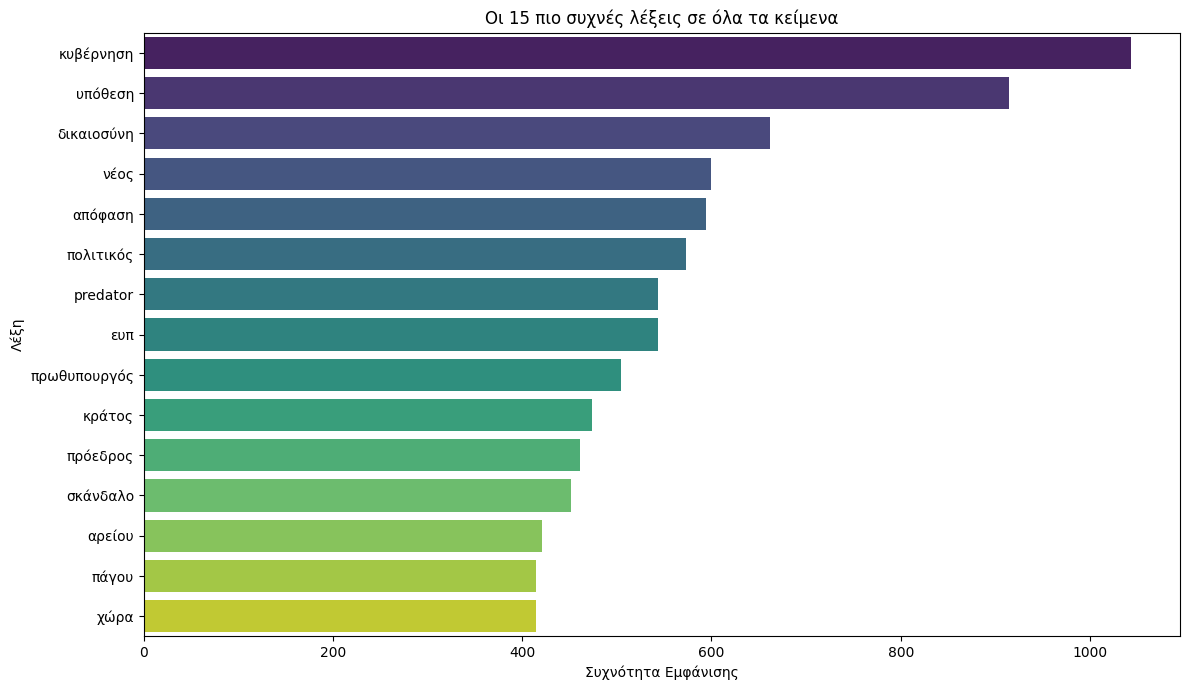

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sum the word counts across all documents to get total frequency for each word
word_frequencies_lemmatized = results_lemmatized.sum(axis=0)

# Get the top 15 most frequent words
top_15_words_lemmatized = word_frequencies_lemmatized.nlargest(15)

# Create a bar chart for the top 15 words
plt.figure(figsize=(12, 7))
sns.barplot(x=top_15_words_lemmatized.values, y=top_15_words_lemmatized.index, palette='viridis')
plt.title('Οι 15 πιο συχνές λέξεις σε όλα τα κείμενα')
plt.xlabel('Συχνότητα Εμφάνισης')
plt.ylabel('Λέξη')
plt.tight_layout()
plt.show()

### Οι 15 πιο συχνές δίγραμμες λέξεις (bigrams) στο λεμματισμένο κείμενο (χωρίς ρήματα)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize CountVectorizer for bigrams on lemmatized text
cv_lemmatized_bigrams = CountVectorizer(stop_words=list(nlp.Defaults.stop_words), ngram_range=(2, 2))

# Transform the lemmatized text (without verbs)
count_vector_lemmatized_bigrams = cv_lemmatized_bigrams.fit_transform([lemmatized_text_no_verbs])

# Create a DataFrame from the transformed data
results_lemmatized_bigrams = pd.DataFrame(count_vector_lemmatized_bigrams.toarray(), columns=cv_lemmatized_bigrams.get_feature_names_out())

/tmp/ipykernel_1533/3696977554.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_bigrams_lemmatized.values, y=top_15_bigrams_lemmatized.index, palette='viridis')


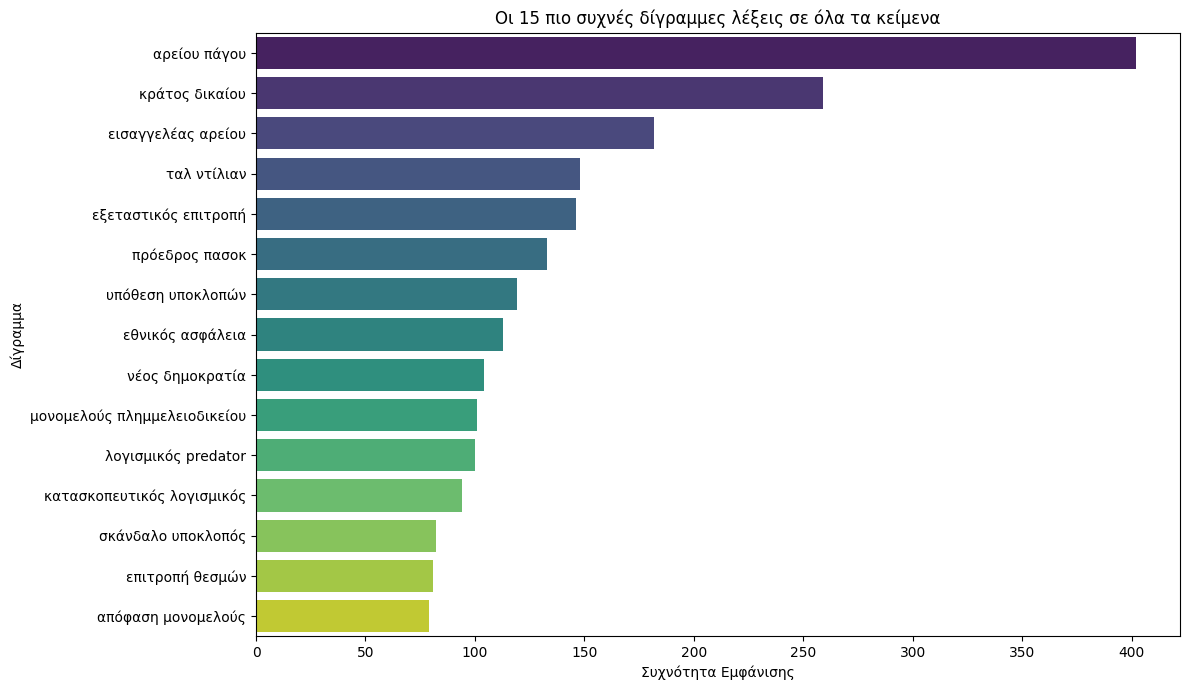

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sum the word counts across all documents to get total frequency for each bigram
word_frequencies_lemmatized_bigrams = results_lemmatized_bigrams.sum(axis=0)

# Get the top 15 most frequent bigrams
top_15_bigrams_lemmatized = word_frequencies_lemmatized_bigrams.nlargest(15)

# Create a bar chart for the top 15 bigrams
plt.figure(figsize=(12, 7))
sns.barplot(x=top_15_bigrams_lemmatized.values, y=top_15_bigrams_lemmatized.index, palette='viridis')
plt.title('Οι 15 πιο συχνές δίγραμμες λέξεις σε όλα τα κείμενα')
plt.xlabel('Συχνότητα Εμφάνισης')
plt.ylabel('Δίγραμμα')
plt.tight_layout()
plt.show()

#Cosine similarity (ομοιότητα κειμένων)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

print("cosine scores ==> ",cosine_similarity(tfidf_matrix_train[0:1], tfidf_matrix_train))

cosine scores ==>  [[1.         0.3816497  0.0528245  0.02556472 0.44202679 0.27856222
  0.05872941 0.05581685 0.20076296 0.19029885 0.         0.04964019
  0.01094118 0.0467903  0.08514991 0.10323925 0.16624575 0.10220594
  0.032201   0.09073671 0.24972549 0.04505678 0.39123584 0.11080246
  0.06654606 0.18935768 0.1469318  0.2403761  0.         0.13214308
  0.14584629 0.05101864 0.03093124 0.19313402 0.11562945 0.06335793
  0.         0.04631581 0.11237199 0.         0.04830998 0.21553816
  0.04306593 0.13458024 0.04427157 0.14875518 0.06723687 0.1685291
  0.02115247 0.11132    0.14675589 0.14356328 0.11253651 0.17655952
  0.27270302 0.28766597 0.07442084 0.19537092 0.2418425  0.21864853
  0.15225206 0.14646682 0.31590393 0.2086238  0.         0.20875308
  0.25101341 0.         0.16060909 0.15445691 0.18900267 0.23486635
  0.22319592 0.39951341 0.39218392 0.19098111 0.26624678 0.40420162
  0.07487421 0.24973833 0.04636953 0.07702314 0.53523958 0.43855887
  0.30014361 0.50359386 0.2479

In [ ]:
arr = cosine_similarity(tfidf_matrix_train, tfidf_matrix_train)

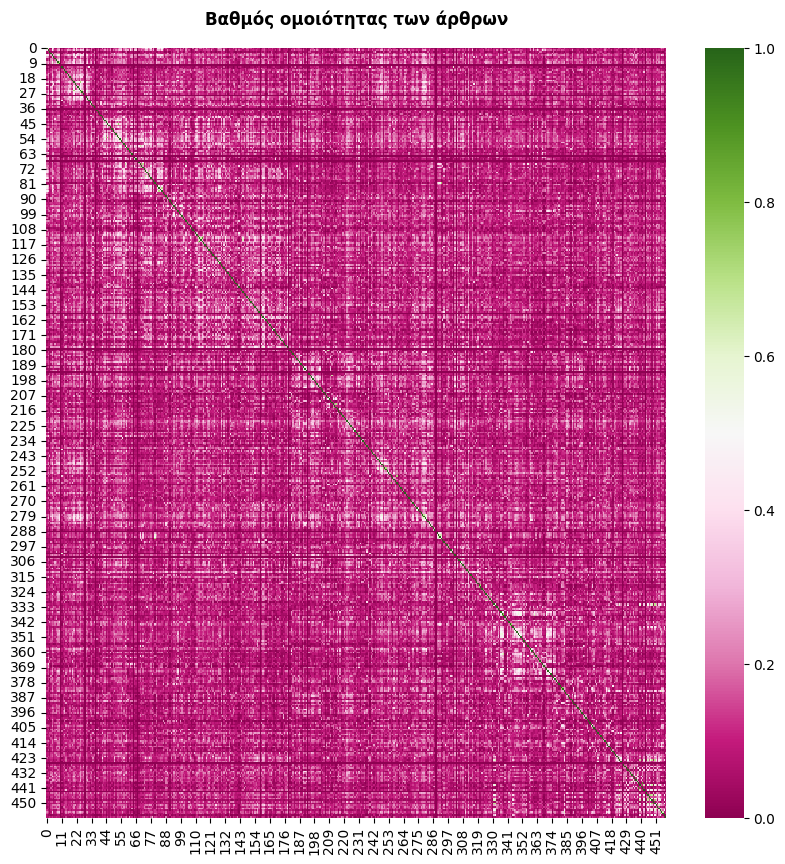

In [ ]:
arr = cosine_similarity(tfidf_matrix_train, tfidf_matrix_train)
plt.figure(figsize=(10, 10))
plt.title('Βαθμός ομοιότητας των άρθρων', y=1.02, fontweight='bold')
sns.heatmap(data=arr, cmap="PiYG")
plt.savefig('efsyn_cosine_similarity_alltexts.png')

### Finding the most similar articles

In [ ]:
import numpy as np

n = arr.shape[0]
similarity_scores = []

# Iterate through the upper triangle of the matrix to avoid duplicate pairs and self-similarity
for i in range(n):
    for j in range(i + 1, n): # Start from i+1 to avoid self-similarity and duplicates
        similarity_scores.append((arr[i, j], i, j))

# Sort the scores in descending order
similarity_scores.sort(key=lambda x: x[0], reverse=True)

print("Top 5 most similar article pairs:")
for score, idx1, idx2 in similarity_scores[:5]:
    print(f"Articles {idx1} and {idx2}: Similarity Score = {score:.4f}")
    # Optionally, you can display the full text of these articles
    # print(f"Article {idx1} content:\n{short_efsyn_df.loc[idx1, 'full_text'][:200]}...") # display first 200 chars
    # print(f"Article {idx2} content:\n{short_efsyn_df.loc[idx2, 'full_text'][:200]}...") # display first 200 chars
    # print("\n---\n")

Top 5 most similar article pairs:
Articles 438 and 441: Similarity Score = 0.8898
Articles 113 and 115: Similarity Score = 0.8753
Articles 337 and 338: Similarity Score = 0.7794
Articles 45 and 53: Similarity Score = 0.7454
Articles 381 and 382: Similarity Score = 0.7454


In [ ]:
print("Displaying content for the top 5 most similar article pairs:")
for score, idx1, idx2 in similarity_scores[:5]:
    print(f"\nArticles {idx1} and {idx2} (Similarity Score = {score:.4f}):")
    print(f"Article {idx1} content:\n{short_efsyn_df.loc[idx1, 'full_text'][:500]}...") # display first 500 chars
    print(f"Article {idx2} content:\n{short_efsyn_df.loc[idx2, 'full_text'][:500]}...") # display first 500 chars
    print("---------------------------------------------------")

Displaying content for the top 5 most similar article pairs:

Articles 438 and 441 (Similarity Score = 0.8898):
Article 438 content:
Πάνω από 7 στους 10 δηλώνουν πεπεισμένοι για κυβερνητική προσπάθεια να «θαφτούν» οι ευθύνες. Άλλη μιαδημοσκόπηση – κόλαφοςγια το Μαξίμου και τον πρωθυπουργόΚυριάκο Μητσοτάκη, με τους πολίτες να αποδοκιμάζουν ουσιαστικά τους κυβερνητικούς χειρισμούς σε ό,τι αφορά τοΚράτος Δικαίουκαι να «καρφώνουν» την κυβέρνηση στα καυτά θέματα τωνΤεμπώνκαι τωνπαρακολουθήσεων. Ειδικότερα, απέναντι στο Μαξίμου στέκονται οι πολίτες της χώρας, όσον αφορά τοκυβερνητικό αφήγημα περί μη συγκάλυψηςστο έγκλημα των Τεμπών...
Article 441 content:
Η προειδοποίηση από την εταιρεία για το ισραηλινό κατασκοπευτικό λογισμικό Paragon και οι καταγγελίες ακτιβιστών στην Ιταλία • Έρευνα και για τη νομιμότητα του DeepSeek. Η Αρχή Προστασίας Δεδομένων ανακοίνωσε ότι ξεκίνησε έρευνα για την υπόθεση που αφορά την παραβίαση προσωπικών δεδομένων χρηστών τoυ WhatsΑpp από κακόβουλο λογισμικό. Η έρευ

In [ ]:
arr = cosine_similarity(tfidf_matrix_train[0:20], tfidf_matrix_train[0:10])

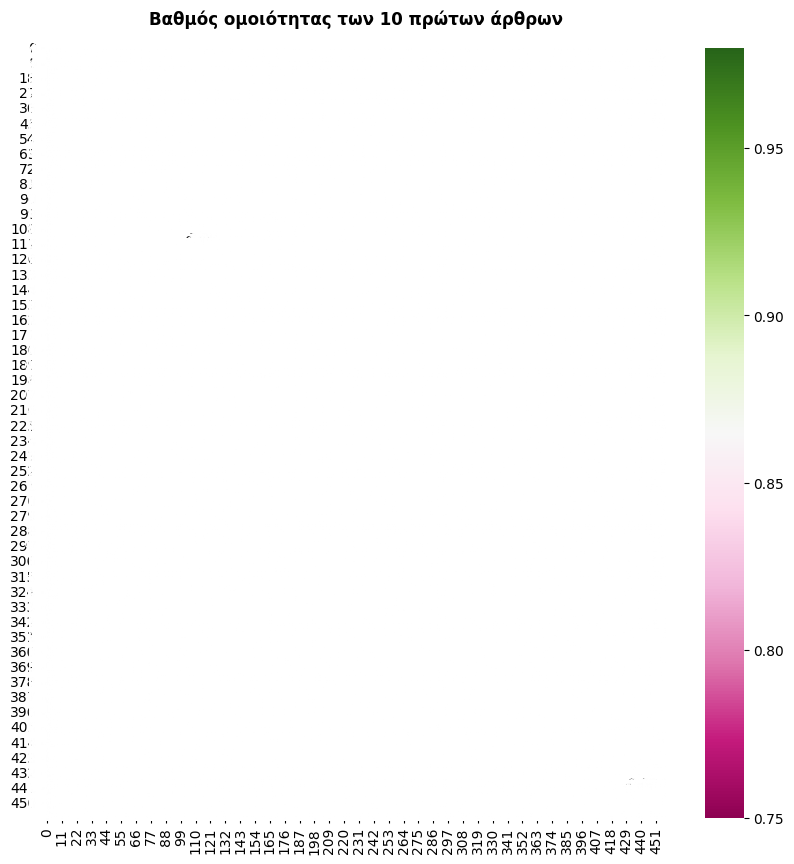

In [ ]:
plt.figure(figsize=(10, 10))
# annot = True to print the values inside the square
plt.title('Βαθμός ομοιότητας των 10 πρώτων άρθρων', y=1.02, fontweight='bold') # το y ορίζει την απόσταση του τίτλου από το γράφημα
sns.heatmap(data=arr, annot=True, vmin=0.75, vmax=0.98, cmap="PiYG")
plt.savefig('efsyn_cosine_similarity_10texts.png')

#Οι πιο συχνοί συγγραφείς άρθρων για τις υποκλοπές

In [ ]:
efsyn_full_articles_df['author'] = efsyn_full_articles_df['author'].astype(str).str.replace('ΕΝΤΥΠΗ ΕΚΔΟΣΗ', '', regex=False).str.strip()

# Recalculate author article counts
author_article_counts = efsyn_full_articles_df['author'].value_counts()
print(author_article_counts)

author
efsyn.gr                                          228
Τάσος Παππάς                                       24
Κώστας Ζαφειρόπουλος                               22
Δανάη Κισκήρα - Μπαρτσώκα                          19
Δημήτρης Κανελλόπουλος                             18
Γεωργία Σάκκουλα                                   14
Κ.ΖΑΦ.                                             13
Θανάσης Καρτερός                                   12
Δημήτρης Κουκλουμπέρης                             10
ΕΦ.ΣΥΝ.                                             9
nan                                                 9
Ολυμπία Λιάτσου                                     9
Νίκος Παπαδημητρίου                                 7
Έλενα Βαρίνου                                       6
Πέτρος Μανταίος                                     5
Μαρία Ψαρά                                          4
Τάσος Παππάς, Δημήτρης Κανελλόπουλος                3
Χάρης Βεργούλης*                                    3
efsyn. gr            

/tmp/ipykernel_1533/640153217.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_authors.values, y=top_15_authors.index, palette='viridis')


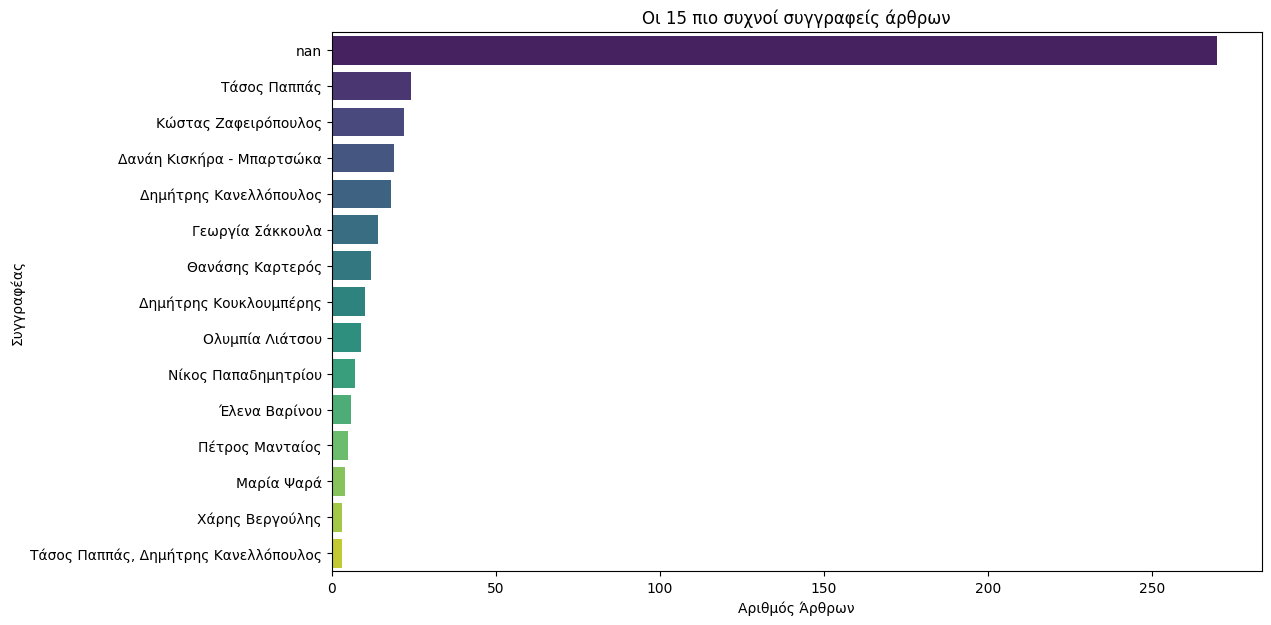

In [ ]:
import numpy as np

# Ensure 'author' column is string type and remove the 'ΕΝΤΥΠΗ ΕΚΔΟΣΗ' prefix and strip whitespace
efsyn_full_articles_df['author'] = efsyn_full_articles_df['author'].astype(str).str.replace('ΕΝΤΥΠΗ ΕΚΔΟΣΗ', '', regex=False).str.strip()

# Replace variations of the publication name and 'nan' string with actual NaN for filtering
efsyn_full_articles_df['author'] = efsyn_full_articles_df['author'].replace(['efsyn.gr', 'efsyn. gr', 'ΕΦ.ΣΥΝ.', 'nan', 'None', ''], np.nan)

# Also replace other known non-authorial entries or abbreviations if they are not expanded
efsyn_full_articles_df['author'] = efsyn_full_articles_df['author'].replace([
    'Κ.ΖΑΦ.', 'ΣΩ.ΜΑ.', 'Γ.ΣΑΚ.', 'Ν.ΠΑΠ.', 'O.X.I.A.', 'Γ.Π.', 'καθώς και το γεγονός'
], np.nan)

# Remove any asterisks from author names and re-strip whitespace
efsyn_full_articles_df['author'] = efsyn_full_articles_df['author'].astype(str).str.replace('*', '', regex=False).str.strip()

# Drop rows where author is NaN (missing or filtered out) for counting
cleaned_authors_df = efsyn_full_articles_df.dropna(subset=['author'])

# Recalculate author article counts on the cleaned data
author_article_counts = cleaned_authors_df['author'].value_counts()

# Select the top 15 most frequent authors
top_15_authors = author_article_counts.head(15)

# Create a bar chart for the top 15 authors
plt.figure(figsize=(12, 7))
sns.barplot(x=top_15_authors.values, y=top_15_authors.index, palette='viridis')
plt.title('Οι 15 πιο συχνοί συγγραφείς άρθρων')
plt.xlabel('Αριθμός Άρθρων')
plt.ylabel('Συγγραφέας')
plt.show()